# Words Test Evaluation Analysis (CNN+BiLSTM+CTC)

In [ ]:
from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple
import json
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
HAS_SEABORN = True


if (Path.cwd() / "src_words").exists():
    PROJECT_ROOT = Path.cwd()
elif Path.cwd().name == "src_words" and (Path.cwd().parent / "src_words").exists():
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"HAS_SEABORN: {HAS_SEABORN}")

PROJECT_ROOT: /mnt/e/HTR/CNN+BiLSTM+CTC
HAS_SEABORN: True


In [2]:
from src_words.architecture import compile_hybrid_network
from src_words.config import (
    FORMS_METADATA,
    IMAGE_DIRECTORY,
    MODEL_DIRECTORY,
    RANDOM_SEED,
    SPLIT_INDEX_FILE,
    SPLIT_TEST_RATIO,
    SPLIT_TRAIN_RATIO,
    SPLIT_VAL_RATIO,
    STRICT_CHARSET_POLICY,
    STRICT_LM_DECODER,
    STRICT_SPLIT_POLICY,
    SEQUENCE_TIME_STEPS,
)
from src_words.dataset_parser import (
    parse_iam_metadata,
    encode_ground_truth,
    compute_ctc_min_timesteps,
)
from src_words.inference_engine import build_replication_lm_decoder, execute_ctc_decoding
from src_words.metrics import aggregate_corpus_metrics, levenshtein_distance
from src_words.preprocessing import execute_morphological_preprocessing
from src_words.split_utils import load_or_create_split_indices

I0000 00:00:1777044127.247829    7310 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777044157.707259    7310 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1777044212.612994    7310 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
WEIGHTS_PATH = os.path.join(MODEL_DIRECTORY, "optimal_hybrid_weights.weights.h5")
REQUIRE_LM = STRICT_LM_DECODER
BATCH_SIZE = 64
TOP_CM_CLASSES = 20
MIN_CLASS_FREQ = 3

OUTPUT_DIR = PROJECT_ROOT / "src_words" / "analysis_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"WEIGHTS_PATH: {WEIGHTS_PATH}")
print(f"REQUIRE_LM: {REQUIRE_LM}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

WEIGHTS_PATH: /mnt/e/HTR/CNN+BiLSTM+CTC/saved_models/optimal_hybrid_weights.weights.h5
REQUIRE_LM: True
OUTPUT_DIR: /mnt/e/HTR/CNN+BiLSTM+CTC/src_words/analysis_outputs


In [4]:
def safe_div(numerator: float, denominator: float) -> float:
    return float(numerator) / float(denominator) if denominator else 0.0


def compute_multiclass_metrics(y_true: List[str], y_pred: List[str]) -> Tuple[Dict[str, float], pd.DataFrame]:
    labels = sorted(set(y_true) | set(y_pred))
    support = Counter(y_true)

    tp = Counter()
    fp = Counter()
    fn = Counter()

    for truth, pred in zip(y_true, y_pred):
        if truth == pred:
            tp[truth] += 1
        else:
            fp[pred] += 1
            fn[truth] += 1

    per_label_rows = []
    for label in labels:
        tpi = tp[label]
        fpi = fp[label]
        fni = fn[label]

        precision_i = safe_div(tpi, tpi + fpi)
        recall_i = safe_div(tpi, tpi + fni)
        f1_i = safe_div(2.0 * precision_i * recall_i, precision_i + recall_i)

        per_label_rows.append(
            {
                "label": label,
                "support": int(support[label]),
                "tp": int(tpi),
                "fp": int(fpi),
                "fn": int(fni),
                "precision": precision_i,
                "recall": recall_i,
                "f1": f1_i,
            }
        )

    per_class_df = pd.DataFrame(per_label_rows)

    macro_precision = float(per_class_df["precision"].mean()) if not per_class_df.empty else 0.0
    macro_recall = float(per_class_df["recall"].mean()) if not per_class_df.empty else 0.0
    macro_f1 = float(per_class_df["f1"].mean()) if not per_class_df.empty else 0.0

    total_support = int(per_class_df["support"].sum()) if not per_class_df.empty else 0
    weighted_precision = (
        float((per_class_df["precision"] * per_class_df["support"]).sum()) / max(total_support, 1)
        if not per_class_df.empty
        else 0.0
    )
    weighted_recall = (
        float((per_class_df["recall"] * per_class_df["support"]).sum()) / max(total_support, 1)
        if not per_class_df.empty
        else 0.0
    )
    weighted_f1 = (
        float((per_class_df["f1"] * per_class_df["support"]).sum()) / max(total_support, 1)
        if not per_class_df.empty
        else 0.0
    )

    total = len(y_true)
    correct = sum(int(t == p) for t, p in zip(y_true, y_pred))
    micro_precision = safe_div(correct, total)
    micro_recall = safe_div(correct, total)
    micro_f1 = safe_div(correct, total)

    metric_summary = {
        "precision_micro": micro_precision,
        "recall_micro": micro_recall,
        "f1_micro": micro_f1,
        "precision_macro": macro_precision,
        "recall_macro": macro_recall,
        "f1_macro": macro_f1,
        "precision_weighted": weighted_precision,
        "recall_weighted": weighted_recall,
        "f1_weighted": weighted_f1,
    }

    return metric_summary, per_class_df


def char_alignment_ops(truth: str, pred: str):
    m, n = len(truth), len(pred)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            substitution_cost = 0 if truth[i - 1] == pred[j - 1] else 1
            dp[i][j] = min(
                dp[i - 1][j] + 1,
                dp[i][j - 1] + 1,
                dp[i - 1][j - 1] + substitution_cost,
            )

    i, j = m, n
    ops = []

    while i > 0 or j > 0:
        if i > 0 and j > 0:
            substitution_cost = 0 if truth[i - 1] == pred[j - 1] else 1
            if dp[i][j] == dp[i - 1][j - 1] + substitution_cost:
                if substitution_cost == 0:
                    ops.append(("match", truth[i - 1], pred[j - 1]))
                else:
                    ops.append(("sub", truth[i - 1], pred[j - 1]))
                i -= 1
                j -= 1
                continue

        if i > 0 and dp[i][j] == dp[i - 1][j] + 1:
            ops.append(("del", truth[i - 1], ""))
            i -= 1
        else:
            ops.append(("ins", "", pred[j - 1]))
            j -= 1

    ops.reverse()
    return ops


def _diagnose_kenlm_module() -> Dict[str, object]:
    details: Dict[str, object] = {
        "import_ok": False,
        "module_file": None,
        "has_model_attr": False,
        "module_repr": None,
    }

    try:
        import kenlm

        details["import_ok"] = True
        details["module_file"] = getattr(kenlm, "__file__", None)
        details["has_model_attr"] = hasattr(kenlm, "Model")
        details["module_repr"] = repr(kenlm)
    except Exception as exc:
        details["module_repr"] = f"{type(exc).__name__}: {exc}"

    return details


def resolve_lm_decoder(require_lm: bool):
    try:
        decoder = build_replication_lm_decoder(required=require_lm)
        return decoder, require_lm, None
    except Exception as exc:
        message = f"{type(exc).__name__}: {exc}"
        lowered = message.lower()

        looks_like_lm_issue = (
            "kenlm" in lowered
            or "pyctcdecode" in lowered
            or "arpa" in lowered
            or "unigram" in lowered
        )

        if require_lm and looks_like_lm_issue:
            diag = _diagnose_kenlm_module()
            fallback_note = (
                "LM decoder unavailable, auto-falling back to CTC-only decoding. "
                f"{message} | kenlm_file={diag['module_file']} | "
                f"kenlm_has_model={diag['has_model_attr']}"
            )
            print("WARNING:", fallback_note)
            return None, False, fallback_note

        raise


def build_prediction_table(weights_path: str, require_lm: bool, batch_size: int = 64):
    corpus = parse_iam_metadata(
        FORMS_METADATA,
        IMAGE_DIRECTORY,
        strict_charset=STRICT_CHARSET_POLICY,
        strict_integrity=True,
    )

    _, _, test_idx = load_or_create_split_indices(
        total_size=len(corpus),
        split_path=SPLIT_INDEX_FILE,
        train_ratio=SPLIT_TRAIN_RATIO,
        val_ratio=SPLIT_VAL_RATIO,
        test_ratio=SPLIT_TEST_RATIO,
        seed=RANDOM_SEED,
        strict=STRICT_SPLIT_POLICY,
    )

    test_subset = [corpus[i] for i in test_idx]
    if not test_subset:
        raise RuntimeError("Test subset is empty.")

    prepared = []
    dropped_samples = 0

    for sample in test_subset:
        truth = sample["transcription"]

        try:
            encoded = encode_ground_truth(truth, strict_charset=True)
        except ValueError:
            dropped_samples += 1
            continue

        if len(encoded) == 0 or len(encoded) > SEQUENCE_TIME_STEPS:
            dropped_samples += 1
            continue

        if compute_ctc_min_timesteps(encoded) > SEQUENCE_TIME_STEPS:
            dropped_samples += 1
            continue

        image_tensor = execute_morphological_preprocessing(sample["path"])
        if image_tensor is None:
            dropped_samples += 1
            continue

        prepared.append(
            {
                "path": sample["path"],
                "truth": truth,
                "image": image_tensor,
            }
        )

    if not prepared:
        raise RuntimeError("No evaluable samples after preprocessing.")

    if not os.path.exists(weights_path):
        raise FileNotFoundError(f"Missing model weights at {weights_path}")

    _, model_inference = compile_hybrid_network()
    model_inference.load_weights(weights_path)

    lm_decoder, decode_require_lm, decoder_fallback_note = resolve_lm_decoder(require_lm=require_lm)

    rows = []
    for start in range(0, len(prepared), batch_size):
        batch = prepared[start:start + batch_size]
        image_batch = np.asarray([sample["image"] for sample in batch], dtype=np.float32)

        probs = model_inference(image_batch, training=False)
        if isinstance(probs, (list, tuple)):
            probs = probs[0]
        probs = np.asarray(probs, dtype=np.float32)

        pred_batch = execute_ctc_decoding(
            probs,
            lm_decoder=lm_decoder,
            require_lm=decode_require_lm,
        )

        if len(pred_batch) != len(batch):
            raise RuntimeError(
                f"Prediction/metadata mismatch in batch: {len(pred_batch)} vs {len(batch)}"
            )

        for sample, pred, sample_probs in zip(batch, pred_batch, probs):
            truth = str(sample["truth"])
            pred = str(pred)

            char_edits = int(levenshtein_distance(pred, truth))
            word_edits = int(levenshtein_distance(pred.split(), truth.split()))

            max_probs = np.max(sample_probs, axis=1)
            max_probs = np.clip(max_probs, 1e-8, 1.0)

            rows.append(
                {
                    "image_path": sample["path"],
                    "image_name": Path(sample["path"]).name,
                    "word_id": Path(sample["path"]).stem,
                    "truth_word": truth,
                    "predicted_word": pred,
                    "is_correct": int(pred == truth),
                    "char_edit_distance": char_edits,
                    "word_edit_distance": word_edits,
                    "cer": safe_div(char_edits, max(len(truth), 1)),
                    "wer": safe_div(word_edits, max(len(truth.split()), 1)),
                    "truth_length": len(truth),
                    "pred_length": len(pred),
                    "length_delta": len(pred) - len(truth),
                    "ctc_confidence_meanmax": float(np.mean(max_probs)),
                    "ctc_confidence_geo": float(np.exp(np.mean(np.log(max_probs)))),
                }
            )

    result_df = pd.DataFrame(rows)

    if decode_require_lm:
        decoder_mode = "lm_ctcdecode"
    elif decoder_fallback_note:
        decoder_mode = "ctc_only_fallback"
    else:
        decoder_mode = "ctc_only"

    run_info = {
        "test_subset_size": len(test_subset),
        "evaluated_samples": len(result_df),
        "dropped_samples": dropped_samples,
        "requested_lm": bool(require_lm),
        "effective_require_lm": bool(decode_require_lm),
        "decoder_mode": decoder_mode,
        "decoder_fallback_note": decoder_fallback_note,
    }

    return result_df, run_info

In [5]:
kenlm_diag = _diagnose_kenlm_module()
print("KenLM diagnostics:")
display(pd.DataFrame([kenlm_diag]))

if REQUIRE_LM and not bool(kenlm_diag.get("has_model_attr", False)):
    print(
        "LM is requested but kenlm.Model is not available in current environment. "
        "Notebook will auto-fallback to CTC-only decoding."
    )

KenLM diagnostics:


,import_ok,module_file,has_model_attr,module_repr
0,True,/mnt/e/HTR/CNN+BiLSTM+CTC/venv/lib/python3.12/...,True,<module 'kenlm' from '/mnt/e/HTR/CNN+BiLSTM+CT...


In [6]:
import importlib
import importlib.util
from importlib.machinery import PathFinder
import site
import subprocess
import sys


def _site_package_candidates() -> List[str]:
    candidates: List[str] = []

    try:
        candidates.extend(site.getsitepackages())
    except Exception:
        pass

    try:
        user_site = site.getusersitepackages()
        if isinstance(user_site, str):
            candidates.append(user_site)
        else:
            candidates.extend(list(user_site))
    except Exception:
        pass

    deduped: List[str] = []
    for path_str in candidates:
        if path_str and path_str not in deduped:
            deduped.append(path_str)

    return deduped


def _purge_module_cache(prefixes: List[str]) -> None:
    for module_name in list(sys.modules.keys()):
        if any(module_name == p or module_name.startswith(p + ".") for p in prefixes):
            sys.modules.pop(module_name, None)


def _import_kenlm_from_site_paths(site_paths: List[str]):
    spec = PathFinder.find_spec("kenlm", site_paths)
    if spec is None or spec.loader is None:
        return None, "No kenlm spec found on site-packages paths"

    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    sys.modules["kenlm"] = module

    module_file = getattr(module, "__file__", None)
    has_model = hasattr(module, "Model")
    return module, f"Loaded kenlm from site-packages: file={module_file}, has_model={has_model}"


def _kenlm_status_snapshot() -> Dict[str, object]:
    snapshot: Dict[str, object] = {
        "python_executable": sys.executable,
        "project_root": str(PROJECT_ROOT),
        "cwd": str(Path.cwd()),
        "project_root_in_sys_path": str(PROJECT_ROOT) in sys.path,
        "local_kenlm_dir_exists": (PROJECT_ROOT / "kenlm").exists(),
        "kenlm_import_ok": False,
        "kenlm_file": None,
        "kenlm_has_model": False,
        "kenlm_repr": None,
    }

    try:
        import kenlm  # type: ignore

        snapshot["kenlm_import_ok"] = True
        snapshot["kenlm_file"] = getattr(kenlm, "__file__", None)
        snapshot["kenlm_has_model"] = hasattr(kenlm, "Model")
        snapshot["kenlm_repr"] = repr(kenlm)
    except Exception as exc:
        snapshot["kenlm_repr"] = f"{type(exc).__name__}: {exc}"

    return snapshot


def _run_pip_command(args: List[str], timeout: int = 1800) -> Dict[str, object]:
    command = [sys.executable, "-m", "pip"] + args

    try:
        completed = subprocess.run(
            command,
            capture_output=True,
            text=True,
            timeout=timeout,
            check=False,
        )
        stdout_tail = "\n".join(completed.stdout.splitlines()[-25:])
        stderr_tail = "\n".join(completed.stderr.splitlines()[-25:])
        return {
            "command": " ".join(command),
            "returncode": completed.returncode,
            "stdout_tail": stdout_tail,
            "stderr_tail": stderr_tail,
        }
    except Exception as exc:
        return {
            "command": " ".join(command),
            "returncode": -1,
            "stdout_tail": "",
            "stderr_tail": f"{type(exc).__name__}: {exc}",
        }


def repair_lm_environment(
    try_install_if_needed: bool = True,
    prefer_local_kenlm_source: bool = True,
) -> Tuple[Dict[str, object], List[Dict[str, object]]]:
    site_paths = _site_package_candidates()
    actions: List[str] = []

    before = _kenlm_status_snapshot()
    actions.append(
        f"Before repair: kenlm_file={before['kenlm_file']}, kenlm_has_model={before['kenlm_has_model']}"
    )

    # Put site-packages ahead of project root path and keep project root at the end.
    for sp in reversed(site_paths):
        if sp in sys.path:
            sys.path.remove(sp)
        sys.path.insert(0, sp)

    project_root_str = str(PROJECT_ROOT)
    if project_root_str in sys.path:
        while project_root_str in sys.path:
            sys.path.remove(project_root_str)
        sys.path.append(project_root_str)
        actions.append("Moved PROJECT_ROOT to end of sys.path")

    _purge_module_cache(["kenlm", "pyctcdecode", "src_words.inference_engine"])

    # First try: force import kenlm only from site-packages.
    forced_module, forced_message = _import_kenlm_from_site_paths(site_paths)
    actions.append(forced_message)

    install_logs: List[Dict[str, object]] = []
    install_attempted = False

    has_model_now = forced_module is not None and hasattr(forced_module, "Model")
    if not has_model_now and try_install_if_needed:
        install_attempted = True

        # Ensure decoder side is available/up-to-date.
        install_logs.append(_run_pip_command(["install", "--upgrade", "pyctcdecode"]))

        local_kenlm = PROJECT_ROOT / "kenlm"
        if prefer_local_kenlm_source and local_kenlm.exists():
            install_logs.append(_run_pip_command(["install", "-e", str(local_kenlm)]))
            actions.append("Attempted kenlm install from local source folder")
        else:
            install_logs.append(_run_pip_command(["install", "--upgrade", "kenlm"]))
            actions.append("Attempted kenlm install from pip package")

        _purge_module_cache(["kenlm", "pyctcdecode", "src_words.inference_engine"])
        forced_module, forced_message = _import_kenlm_from_site_paths(site_paths)
        actions.append("Post-install import check: " + forced_message)

    final_has_model = forced_module is not None and hasattr(forced_module, "Model")

    decoder_build_ok = False
    decoder_error = None

    if final_has_model:
        try:
            import src_words.inference_engine as _inference_engine

            _inference_engine = importlib.reload(_inference_engine)

            globals()["build_replication_lm_decoder"] = _inference_engine.build_replication_lm_decoder
            globals()["execute_ctc_decoding"] = _inference_engine.execute_ctc_decoding

            globals()["REQUIRE_LM"] = True

            decoder_obj = build_replication_lm_decoder(required=True)
            decoder_build_ok = decoder_obj is not None
            actions.append("Decoder build test succeeded with required=True")
        except Exception as exc:
            decoder_error = f"{type(exc).__name__}: {exc}"
            actions.append("Decoder build test failed")

    after = _kenlm_status_snapshot()

    result = {
        "python_executable": sys.executable,
        "site_paths_count": len(site_paths),
        "before_kenlm_file": before["kenlm_file"],
        "before_kenlm_has_model": before["kenlm_has_model"],
        "after_kenlm_file": after["kenlm_file"],
        "after_kenlm_has_model": after["kenlm_has_model"],
        "install_attempted": install_attempted,
        "decoder_build_ok": decoder_build_ok,
        "decoder_error": decoder_error,
        "actions": " | ".join(actions),
    }

    return result, install_logs


TRY_INSTALL_IF_NEEDED = True
PREFER_LOCAL_KENLM_SOURCE = True

lm_repair_result, lm_install_logs = repair_lm_environment(
    try_install_if_needed=TRY_INSTALL_IF_NEEDED,
    prefer_local_kenlm_source=PREFER_LOCAL_KENLM_SOURCE,
)

print("LM repair result:")
display(pd.DataFrame([lm_repair_result]))

if lm_install_logs:
    print("\nInstall command logs (tail):")
    display(pd.DataFrame(lm_install_logs))

if not bool(lm_repair_result["after_kenlm_has_model"]):
    print(
        "\nLM still unavailable. Keep fallback enabled, or re-run this cell after ensuring build tools "
        "(CMake + C++ compiler) are installed for local kenlm build."
    )
else:
    print("\nLM looks healthy now. Re-run the evaluation cell (the next code cell) for real LM decoding.")

LM repair result:


,python_executable,site_paths_count,before_kenlm_file,before_kenlm_has_model,after_kenlm_file,after_kenlm_has_model,install_attempted,decoder_build_ok,decoder_error,actions
0,/mnt/e/HTR/CNN+BiLSTM+CTC/venv/bin/python3,5,/mnt/e/HTR/CNN+BiLSTM+CTC/venv/lib/python3.12/...,True,/mnt/e/HTR/CNN+BiLSTM+CTC/venv/lib/python3.12/...,True,False,True,None,Before repair: kenlm_file=/mnt/e/HTR/CNN+BiLST...



LM looks healthy now. Re-run the evaluation cell (the next code cell) for real LM decoding.


In [7]:
predictions_df, run_info = build_prediction_table(
    weights_path=WEIGHTS_PATH,
    require_lm=REQUIRE_LM,
    batch_size=BATCH_SIZE,
)

truths = predictions_df["truth_word"].astype(str).tolist()
preds = predictions_df["predicted_word"].astype(str).tolist()

core_metrics = aggregate_corpus_metrics(preds, truths)
cls_metrics, per_class_df = compute_multiclass_metrics(truths, preds)

overall_accuracy_pct = 100.0 * float(predictions_df["is_correct"].mean())

summary = {
    "evaluated_samples": int(len(predictions_df)),
    "exact_match_accuracy_pct": overall_accuracy_pct,
    "sequence_accuracy_pct": float(core_metrics["sequence_accuracy"]),
    "word_accuracy_pct": float(core_metrics["word_accuracy"]),
    "character_accuracy_pct": float(core_metrics["character_accuracy"]),
    "wer_avg": float(core_metrics["wer"]),
    "cer_avg": float(core_metrics["cer"]),
    "wer_global": float(core_metrics["global_wer"]),
    "cer_global": float(core_metrics["global_cer"]),
    "precision_micro": float(cls_metrics["precision_micro"]),
    "recall_micro": float(cls_metrics["recall_micro"]),
    "f1_micro": float(cls_metrics["f1_micro"]),
    "precision_macro": float(cls_metrics["precision_macro"]),
    "recall_macro": float(cls_metrics["recall_macro"]),
    "f1_macro": float(cls_metrics["f1_macro"]),
    "precision_weighted": float(cls_metrics["precision_weighted"]),
    "recall_weighted": float(cls_metrics["recall_weighted"]),
    "f1_weighted": float(cls_metrics["f1_weighted"]),
}

summary_df = pd.DataFrame([summary]).T.reset_index()
summary_df.columns = ["metric", "value"]

print("Run info:", run_info)
display(summary_df)
display(predictions_df.head(10))

2026-04-24 15:27:37,705 - src_words.dataset_parser - [INFO] - Word metadata ingestion complete. Total verified samples: 96454


E0000 00:00:1777045056.100041    7310 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


2026-04-24 15:37:37,276 - src_words.architecture - [INFO] - CNN-BiLSTM-CTC architecture compiled. Spatial tensor constrained to (32, 256).


2026-04-24 15:48:45,352 - src_words.metrics - [INFO] - SeqAcc: 94.68% | WordAcc: 94.67% | CharAcc: 97.97% | WER(avg): 0.0532 | CER(avg): 0.0319 | WER(global): 0.0533 | CER(global): 0.0203


Run info: {'test_subset_size': 19292, 'evaluated_samples': 19292, 'dropped_samples': 0, 'requested_lm': True, 'effective_require_lm': True, 'decoder_mode': 'lm_ctcdecode', 'decoder_fallback_note': None}


,metric,value
0,evaluated_samples,19292.000000
1,exact_match_accuracy_pct,94.681733
2,sequence_accuracy_pct,94.681733
3,word_accuracy_pct,94.672471
4,character_accuracy_pct,97.969373
5,wer_avg,0.053235
6,cer_avg,0.031940
7,wer_global,0.053275
8,cer_global,0.020306
9,precision_micro,0.946817


,image_path,image_name,word_id,truth_word,predicted_word,is_correct,char_edit_distance,word_edit_distance,cer,wer,truth_length,pred_length,length_delta,ctc_confidence_meanmax,ctc_confidence_geo
0,/mnt/e/HTR/CNN+BiLSTM+CTC/data/words/e02/e02-1...,e02-100-05-03.png,e02-100-05-03,the,the,1,0,0,0.000000,0.0,3,3,0,0.999371,0.999367
1,/mnt/e/HTR/CNN+BiLSTM+CTC/data/words/k04/k04-1...,k04-126-02-07.png,k04-126-02-07,to,to,1,0,0,0.000000,0.0,2,2,0,0.999941,0.999941
2,/mnt/e/HTR/CNN+BiLSTM+CTC/data/words/b05/b05-0...,b05-058-02-10.png,b05-058-02-10,only,sly,0,2,1,0.500000,1.0,4,3,-1,0.983671,0.982389
3,/mnt/e/HTR/CNN+BiLSTM+CTC/data/words/h07/h07-0...,h07-066b-05-02.png,h07-066b-05-02,",",",",1,0,0,0.000000,0.0,1,1,0,0.996749,0.996573
4,/mnt/e/HTR/CNN+BiLSTM+CTC/data/words/c03/c03-0...,c03-000c-00-05.png,c03-000c-00-05,Shelagh,thelagh,0,1,1,0.142857,1.0,7,7,0,0.951111,0.941089
5,/mnt/e/HTR/CNN+BiLSTM+CTC/data/words/c03/c03-0...,c03-087b-05-08.png,c03-087b-05-08,not,not,1,0,0,0.000000,0.0,3,3,0,0.985948,0.981855
6,/mnt/e/HTR/CNN+BiLSTM+CTC/data/words/d04/d04-0...,d04-032-08-07.png,d04-032-08-07,on,on,1,0,0,0.000000,0.0,2,2,0,0.997395,0.997304
7,/mnt/e/HTR/CNN+BiLSTM+CTC/data/words/c03/c03-0...,c03-087e-01-04.png,c03-087e-01-04,by,by,1,0,0,0.000000,0.0,2,2,0,0.989492,0.987450
8,/mnt/e/HTR/CNN+BiLSTM+CTC/data/words/g04/g04-0...,g04-072-01-01.png,g04-072-01-01,",",",",1,0,0,0.000000,0.0,1,1,0,0.998426,0.998387
9,/mnt/e/HTR/CNN+BiLSTM+CTC/data/words/r03/r03-0...,r03-056-00-10.png,r03-056-00-10,she,she,1,0,0,0.000000,0.0,3,3,0,0.985143,0.982506


In [8]:
timestamp = pd.Timestamp.now(tz="UTC").strftime("%Y%m%d_%H%M%S")
artifact_prefix = f"words_test_eval_{timestamp}"

full_csv_path = OUTPUT_DIR / f"{artifact_prefix}_predictions.csv"
wrong_csv_path = OUTPUT_DIR / f"{artifact_prefix}_wrong_predictions.csv"
wrong_paths_txt_path = OUTPUT_DIR / f"{artifact_prefix}_wrong_image_paths.txt"
metrics_json_path = OUTPUT_DIR / f"{artifact_prefix}_metrics.json"
excel_path = OUTPUT_DIR / f"{artifact_prefix}_predictions.xlsx"

predictions_df.to_csv(full_csv_path, index=False, encoding="utf-8")

wrong_df = predictions_df[predictions_df["is_correct"] == 0].copy()
wrong_df.to_csv(wrong_csv_path, index=False, encoding="utf-8")
wrong_df["image_path"].to_csv(wrong_paths_txt_path, index=False, header=False, encoding="utf-8")

with open(metrics_json_path, "w", encoding="utf-8") as file_buffer:
    json.dump(
        {
            "run_info": run_info,
            "summary": summary,
            "core_metrics": core_metrics,
            "classification_metrics": cls_metrics,
        },
        file_buffer,
        indent=2,
    )

excel_status = "not_attempted"
try:
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        predictions_df.to_excel(writer, sheet_name="all_predictions", index=False)
        wrong_df.to_excel(writer, sheet_name="wrong_predictions", index=False)
        pd.DataFrame([summary]).to_excel(writer, sheet_name="summary", index=False)
        per_class_df.sort_values("support", ascending=False).head(2000).to_excel(
            writer,
            sheet_name="per_class_top",
            index=False,
        )
    excel_status = f"saved: {excel_path}"
except Exception as exc:
    excel_status = f"skipped ({type(exc).__name__}: {exc})"

print(f"Saved full CSV: {full_csv_path}")
print(f"Saved wrong CSV: {wrong_csv_path}")
print(f"Saved wrong image paths: {wrong_paths_txt_path}")
print(f"Saved metrics JSON: {metrics_json_path}")
print(f"Excel status: {excel_status}")
print(f"Wrong predictions count: {len(wrong_df)}")

Saved full CSV: /mnt/e/HTR/CNN+BiLSTM+CTC/src_words/analysis_outputs/words_test_eval_20260424_154845_predictions.csv
Saved wrong CSV: /mnt/e/HTR/CNN+BiLSTM+CTC/src_words/analysis_outputs/words_test_eval_20260424_154845_wrong_predictions.csv
Saved wrong image paths: /mnt/e/HTR/CNN+BiLSTM+CTC/src_words/analysis_outputs/words_test_eval_20260424_154845_wrong_image_paths.txt
Saved metrics JSON: /mnt/e/HTR/CNN+BiLSTM+CTC/src_words/analysis_outputs/words_test_eval_20260424_154845_metrics.json
Excel status: saved: /mnt/e/HTR/CNN+BiLSTM+CTC/src_words/analysis_outputs/words_test_eval_20260424_154845_predictions.xlsx
Wrong predictions count: 1026


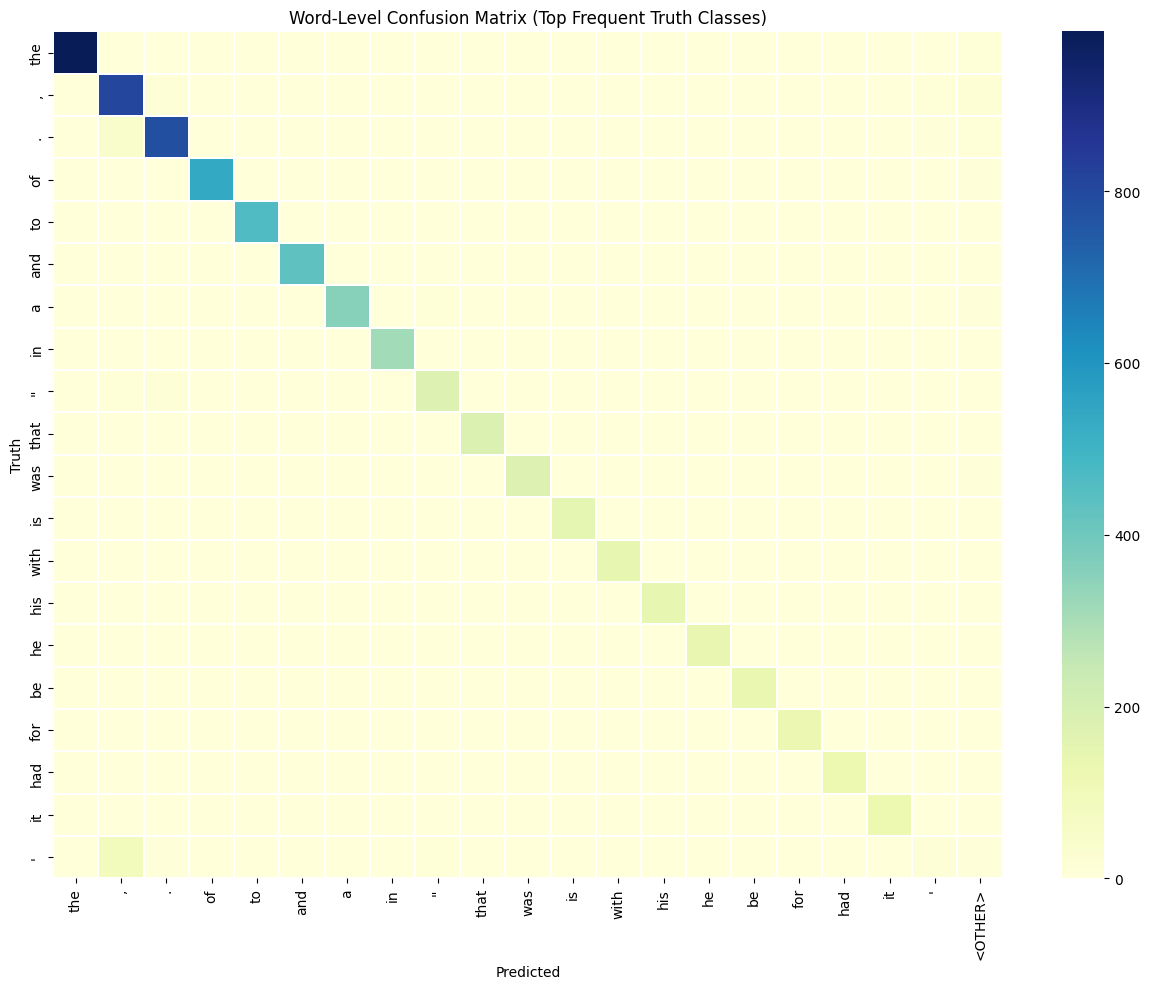

Saved confusion matrix CSV: /mnt/e/HTR/CNN+BiLSTM+CTC/src_words/analysis_outputs/words_test_eval_20260424_154845_word_confusion_matrix.csv
Saved confusion matrix image: /mnt/e/HTR/CNN+BiLSTM+CTC/src_words/analysis_outputs/words_test_eval_20260424_154845_word_confusion_matrix.png


pred_for_cm,the,",",.,of,to,and,a,in,"""",that,...,is,with,his,he,be,for,had,it,',<OTHER>
truth_word,,,,,,,,,,,,,,,,,,,,,
the,986,0,0,0,1,0,0,0,0,0,...,0,0,0,3,0,0,0,0,0,9
",",0,807,12,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,9,18
.,0,40,784,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,5,11
of,0,0,0,537,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
to,0,0,0,0,465,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,3
and,0,0,0,0,0,435,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
a,1,1,2,0,0,0,355,0,10,0,...,0,0,0,0,0,0,0,1,0,7
in,0,0,0,0,0,0,0,311,0,0,...,1,0,0,0,0,0,0,0,0,0
"""",0,9,14,0,0,0,0,1,180,0,...,1,0,0,0,1,0,0,1,2,2


In [9]:
artifact_prefix = globals().get("artifact_prefix", f"words_test_eval_{pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%S')}")

truth_counts = predictions_df["truth_word"].value_counts()
focus_labels = truth_counts[truth_counts >= MIN_CLASS_FREQ].head(TOP_CM_CLASSES).index.tolist()

if len(focus_labels) == 0:
    print("No classes meet MIN_CLASS_FREQ. Lower MIN_CLASS_FREQ to build confusion matrix.")
else:
    cm_source = predictions_df[predictions_df["truth_word"].isin(focus_labels)].copy()
    cm_source["pred_for_cm"] = np.where(
        cm_source["predicted_word"].isin(focus_labels),
        cm_source["predicted_word"],
        "<OTHER>",
    )

    cm_df = pd.crosstab(cm_source["truth_word"], cm_source["pred_for_cm"])

    desired_cols = focus_labels + (["<OTHER>"] if "<OTHER>" in cm_df.columns else [])
    for col in desired_cols:
        if col not in cm_df.columns:
            cm_df[col] = 0

    cm_df = cm_df.reindex(index=focus_labels, columns=desired_cols, fill_value=0)

    cm_csv_path = OUTPUT_DIR / f"{artifact_prefix}_word_confusion_matrix.csv"
    cm_png_path = OUTPUT_DIR / f"{artifact_prefix}_word_confusion_matrix.png"

    cm_df.to_csv(cm_csv_path, encoding="utf-8")

    plt.figure(figsize=(max(10, len(cm_df.columns) * 0.6), max(6, len(cm_df.index) * 0.5)))
    if HAS_SEABORN:
        sns.heatmap(cm_df, annot=False, cmap="YlGnBu", linewidths=0.2)
    else:
        plt.imshow(cm_df.values, aspect="auto", cmap="YlGnBu")
        plt.xticks(range(len(cm_df.columns)), cm_df.columns.tolist(), rotation=90)
        plt.yticks(range(len(cm_df.index)), cm_df.index.tolist())
        plt.colorbar(label="Count")

    plt.title("Word-Level Confusion Matrix (Top Frequent Truth Classes)")
    plt.xlabel("Predicted")
    plt.ylabel("Truth")
    plt.tight_layout()
    plt.savefig(cm_png_path, dpi=180)
    plt.show()

    print(f"Saved confusion matrix CSV: {cm_csv_path}")
    print(f"Saved confusion matrix image: {cm_png_path}")
    display(cm_df.head(10))

Saved substitutions: /mnt/e/HTR/CNN+BiLSTM+CTC/src_words/analysis_outputs/words_test_eval_20260424_154845_char_substitutions.csv
Saved insertions: /mnt/e/HTR/CNN+BiLSTM+CTC/src_words/analysis_outputs/words_test_eval_20260424_154845_char_insertions.csv
Saved deletions: /mnt/e/HTR/CNN+BiLSTM+CTC/src_words/analysis_outputs/words_test_eval_20260424_154845_char_deletions.csv
Saved length-wise metrics: /mnt/e/HTR/CNN+BiLSTM+CTC/src_words/analysis_outputs/words_test_eval_20260424_154845_lengthwise_metrics.csv
Saved hard truth words: /mnt/e/HTR/CNN+BiLSTM+CTC/src_words/analysis_outputs/words_test_eval_20260424_154845_hard_truth_words.csv

Top character substitutions:


,truth_char,pred_char,count
35,',",",91
36,.,",",40
140,a,o,35
66,o,a,29
4,I,",",24
19,s,r,21
31,e,a,16
29,t,l,16
28,m,n,16
26,e,o,16



Top inserted characters:


,inserted_char,count
3,t,14
8,r,12
7,e,11
0,i,10
1,.,9
5,s,8
13,c,8
4,n,7
11,o,5
17,a,4



Top deleted characters:


,deleted_char,count
4,e,31
3,r,30
1,s,27
6,t,25
14,a,18
0,o,17
19,c,16
15,u,13
5,n,12
13,l,11


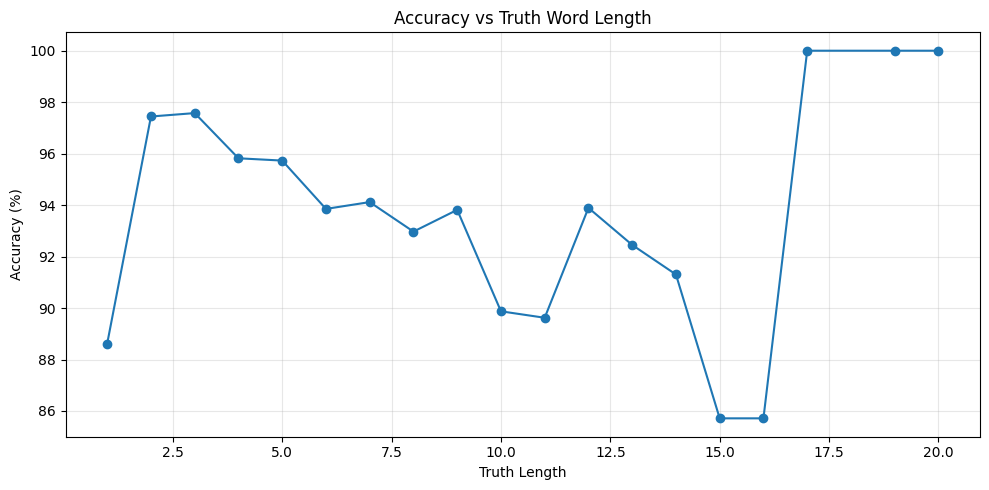

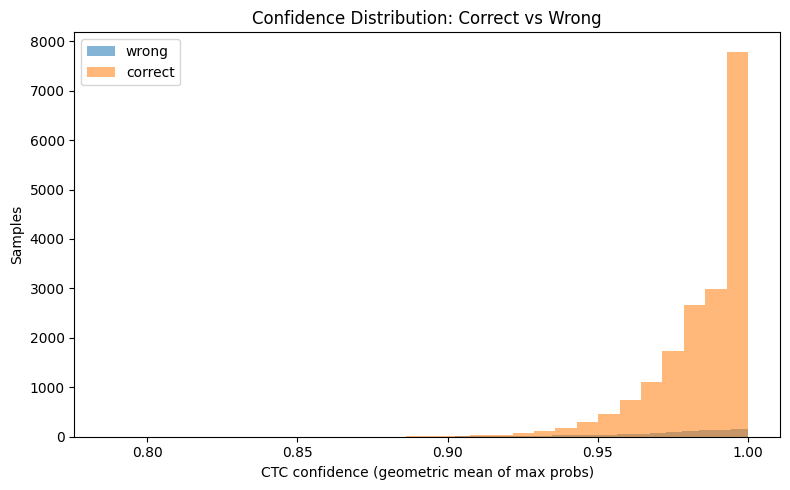


Actionable recommendations:
1. Several frequent truth words have high error rates: add targeted augmentation and hard-example replay for those tokens.
2. Model confidence is high despite errors: calibrate decoder and inspect label noise or lexicon mismatch.

Most difficult truth words (min 5 samples):


,samples,errors,error_rate
truth_word,,,
Of,5,5,1.000000
',122,110,0.901639
1,5,3,0.600000
#,11,5,0.454545
enjoyed,6,2,0.333333
same,6,2,0.333333
show,6,2,0.333333
take,6,2,0.333333
success,10,3,0.300000


In [10]:
artifact_prefix = globals().get("artifact_prefix", f"words_test_eval_{pd.Timestamp.now(tz='UTC').strftime('%Y%m%d_%H%M%S')}")

sub_counter = Counter()
ins_counter = Counter()
del_counter = Counter()

for row in wrong_df.itertuples(index=False):
    truth = str(row.truth_word)
    pred = str(row.predicted_word)
    for op, t_char, p_char in char_alignment_ops(truth, pred):
        if op == "sub":
            sub_counter[(t_char, p_char)] += 1
        elif op == "ins":
            ins_counter[p_char] += 1
        elif op == "del":
            del_counter[t_char] += 1

top_sub_df = pd.DataFrame(
    [
        {"truth_char": t, "pred_char": p, "count": c}
        for (t, p), c in sub_counter.items()
    ]
).sort_values("count", ascending=False) if sub_counter else pd.DataFrame(columns=["truth_char", "pred_char", "count"])

top_ins_df = pd.DataFrame(
    [{"inserted_char": ch, "count": c} for ch, c in ins_counter.items()]
).sort_values("count", ascending=False) if ins_counter else pd.DataFrame(columns=["inserted_char", "count"])

top_del_df = pd.DataFrame(
    [{"deleted_char": ch, "count": c} for ch, c in del_counter.items()]
).sort_values("count", ascending=False) if del_counter else pd.DataFrame(columns=["deleted_char", "count"])

length_df = predictions_df.groupby("truth_length", as_index=False).agg(
    samples=("is_correct", "size"),
    accuracy=("is_correct", "mean"),
    avg_cer=("cer", "mean"),
    avg_wer=("wer", "mean"),
)
length_df["accuracy_pct"] = 100.0 * length_df["accuracy"]

truth_count_df = predictions_df.groupby("truth_word").size().rename("samples").to_frame()
truth_count_df["errors"] = wrong_df.groupby("truth_word").size()
truth_count_df = truth_count_df.fillna(0).astype(int)
truth_count_df["error_rate"] = truth_count_df["errors"] / truth_count_df["samples"]
hard_words_df = truth_count_df.sort_values(["error_rate", "samples"], ascending=[False, False])

sub_csv = OUTPUT_DIR / f"{artifact_prefix}_char_substitutions.csv"
ins_csv = OUTPUT_DIR / f"{artifact_prefix}_char_insertions.csv"
del_csv = OUTPUT_DIR / f"{artifact_prefix}_char_deletions.csv"
len_csv = OUTPUT_DIR / f"{artifact_prefix}_lengthwise_metrics.csv"
hard_csv = OUTPUT_DIR / f"{artifact_prefix}_hard_truth_words.csv"

top_sub_df.to_csv(sub_csv, index=False, encoding="utf-8")
top_ins_df.to_csv(ins_csv, index=False, encoding="utf-8")
top_del_df.to_csv(del_csv, index=False, encoding="utf-8")
length_df.to_csv(len_csv, index=False, encoding="utf-8")
hard_words_df.reset_index().rename(columns={"index": "truth_word"}).to_csv(hard_csv, index=False, encoding="utf-8")

print(f"Saved substitutions: {sub_csv}")
print(f"Saved insertions: {ins_csv}")
print(f"Saved deletions: {del_csv}")
print(f"Saved length-wise metrics: {len_csv}")
print(f"Saved hard truth words: {hard_csv}")

print("\nTop character substitutions:")
display(top_sub_df.head(20))
print("\nTop inserted characters:")
display(top_ins_df.head(20))
print("\nTop deleted characters:")
display(top_del_df.head(20))

plt.figure(figsize=(10, 5))
plt.plot(length_df["truth_length"], length_df["accuracy_pct"], marker="o")
plt.title("Accuracy vs Truth Word Length")
plt.xlabel("Truth Length")
plt.ylabel("Accuracy (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
for is_correct_value, group_df in predictions_df.groupby("is_correct"):
    label = "correct" if int(is_correct_value) == 1 else "wrong"
    plt.hist(group_df["ctc_confidence_geo"], bins=30, alpha=0.55, label=label)
plt.title("Confidence Distribution: Correct vs Wrong")
plt.xlabel("CTC confidence (geometric mean of max probs)")
plt.ylabel("Samples")
plt.legend()
plt.tight_layout()
plt.show()

recommendations = []

if summary["cer_avg"] > 0.12:
    recommendations.append("CER is relatively high: prioritize character-level augmentation (blur/noise/slant) and tune preprocessing thresholds.")
if summary["wer_avg"] > 0.12:
    recommendations.append("WER is relatively high: improve language model coverage (unigrams/corpus cleanup) and retune LM alpha/beta.")

total_sub = int(sum(sub_counter.values()))
total_ins = int(sum(ins_counter.values()))
total_del = int(sum(del_counter.values()))

if total_ins > max(total_del, total_sub):
    recommendations.append("Insertions dominate errors: reduce beam width or LM beta, and inspect over-segmentation artifacts.")
if total_del > max(total_ins, total_sub):
    recommendations.append("Deletions dominate errors: consider stronger image contrast normalization and slightly larger decode beam width.")

if not wrong_df.empty:
    hard_bucket = hard_words_df[(hard_words_df["samples"] >= 5) & (hard_words_df["error_rate"] >= 0.4)]
    if not hard_bucket.empty:
        recommendations.append("Several frequent truth words have high error rates: add targeted augmentation and hard-example replay for those tokens.")

if predictions_df["ctc_confidence_geo"].median() > 0.90 and summary["exact_match_accuracy_pct"] < 95:
    recommendations.append("Model confidence is high despite errors: calibrate decoder and inspect label noise or lexicon mismatch.")

if not recommendations:
    recommendations.append("Current metrics look stable. Next focus: evaluate with external test handwriting styles and perform LM/grid-search tuning.")

print("\nActionable recommendations:")
for idx, rec in enumerate(recommendations, start=1):
    print(f"{idx}. {rec}")

print("\nMost difficult truth words (min 5 samples):")
display(hard_words_df[hard_words_df["samples"] >= 5].head(20))

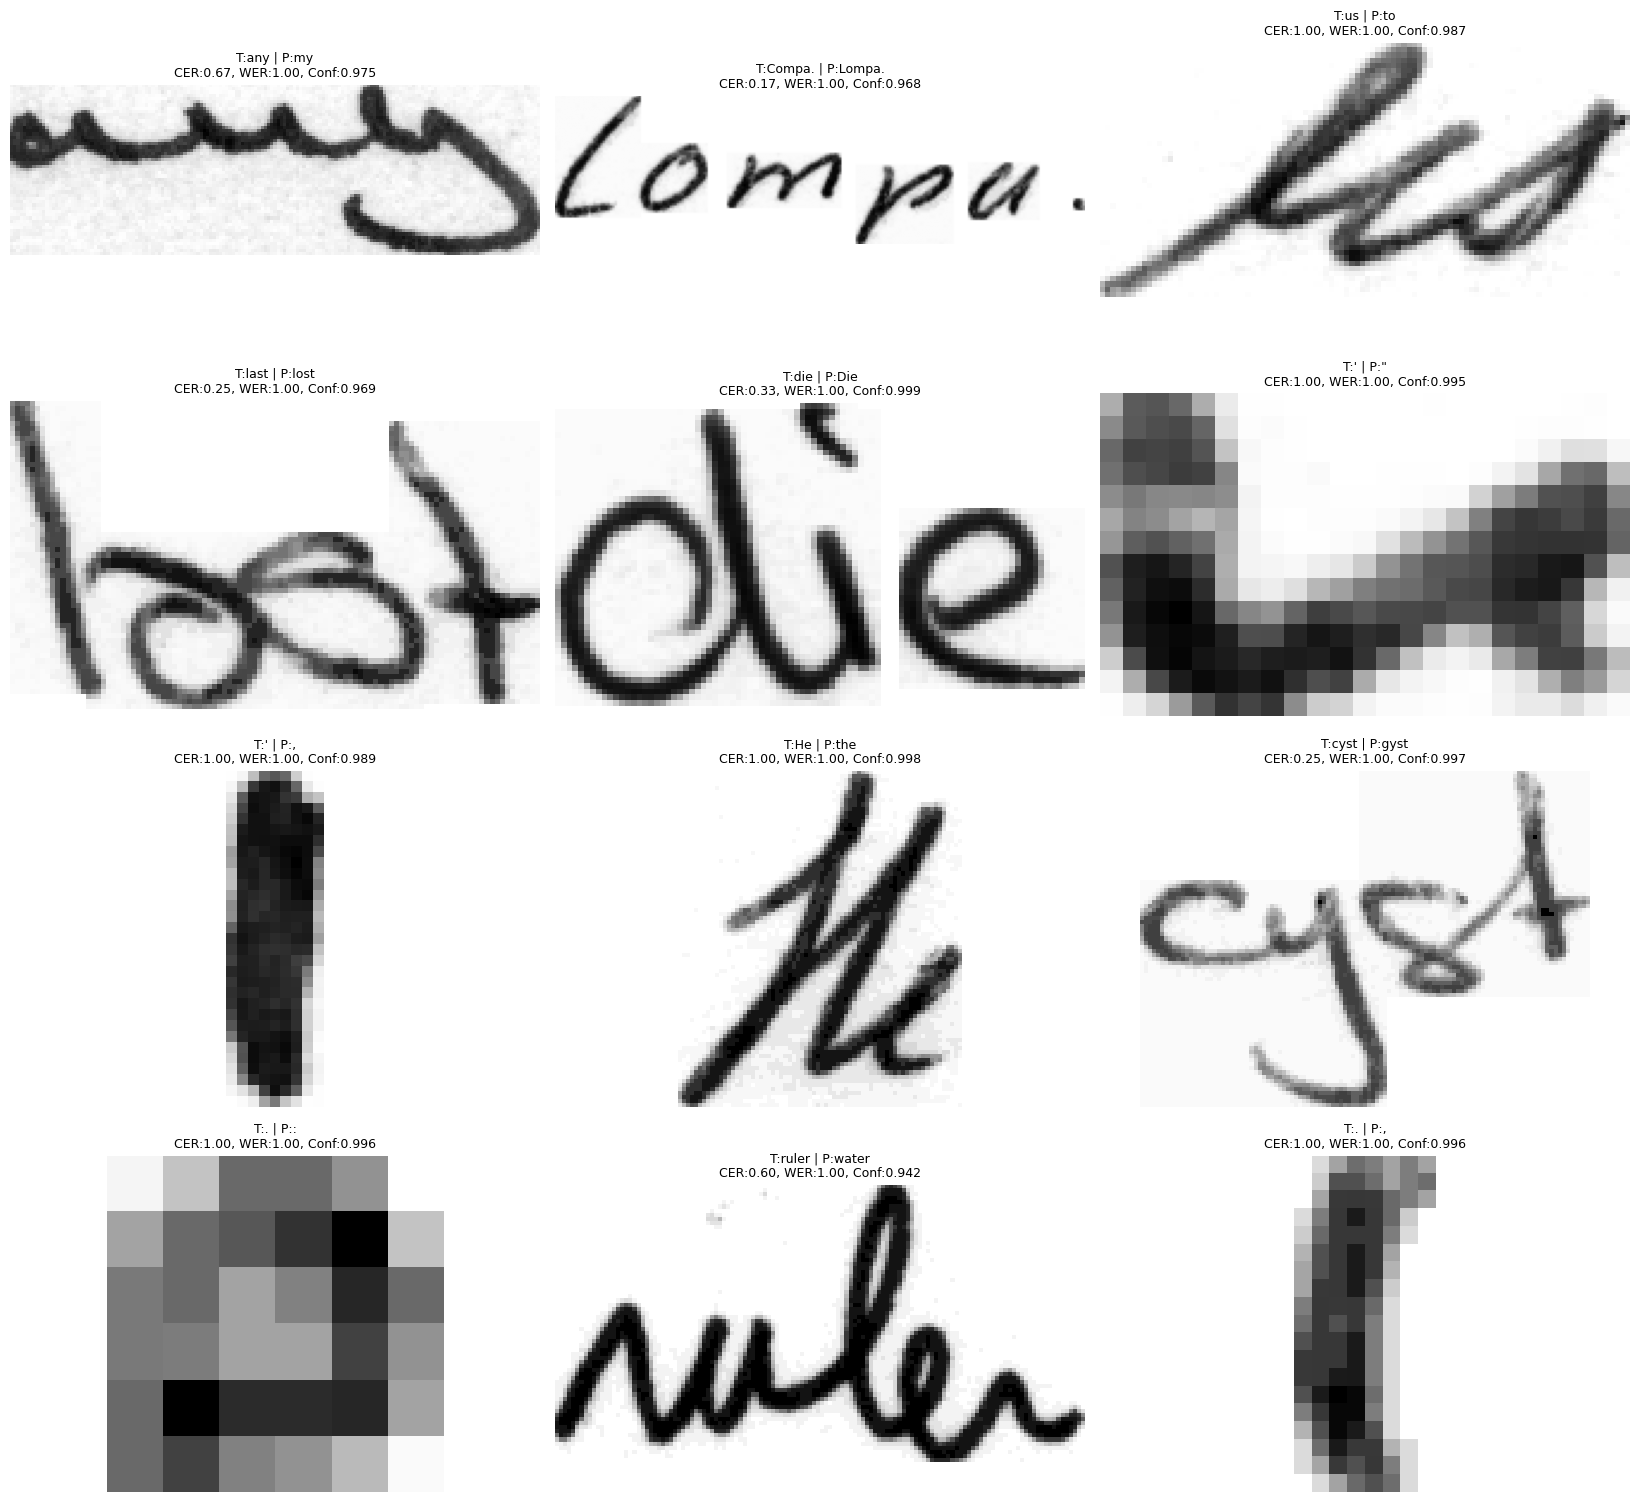

In [11]:
import cv2


def show_wrong_examples(df_wrong: pd.DataFrame, n: int = 12, seed: int = 52) -> None:
    if df_wrong.empty:
        print("No wrong predictions to visualize.")
        return

    sample_df = df_wrong.sample(n=min(n, len(df_wrong)), random_state=seed)

    cols = 3
    rows = int(np.ceil(len(sample_df) / cols))
    plt.figure(figsize=(5.5 * cols, 3.8 * rows))

    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)

        plt.subplot(rows, cols, i)
        if img is not None:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(np.zeros((32, 128), dtype=np.float32), cmap="gray")

        plt.axis("off")
        plt.title(
            f"T:{row['truth_word']} | P:{row['predicted_word']}\n"
            f"CER:{row['cer']:.2f}, WER:{row['wer']:.2f}, Conf:{row['ctc_confidence_geo']:.3f}",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()


show_wrong_examples(wrong_df, n=12)